#  Recommendation and Review Insights

In [ ]:
import pandas as pd

df = pd.read_csv('ClusteredData.csv')
df.head()

,Timestamp,age,Gender,Purchase_Frequency,Purchase_Categories,Browsing_Frequency,Product_Search_Method,Search_Result_Exploration,Customer_Reviews_Importance,Add_to_Cart_Browsing,...,Recommendation_Helpfulness,Rating_Accuracy,Shopping_Satisfaction,Service_Appreciation,Improvement_Areas,transaction,Purchase_Frequency_Level,Cart_Completion_Frequency_Level,Customer_Segmentation,Cluster
0,2023/06/07 11:06:40 PM GMT+5:30,59,Others,Once a week,Beauty and Personal Care,Few times a month,others,Multiple pages,4,Yes,...,Yes,3,3,Customer service,User interface of app,433348,4,2,Occasional Shopper,0
1,2023/06/06 7:08:47 PM GMT+5:30,48,Female,Once a month,Beauty and Personal Care;Clothing and Fashion;...,Rarely,categories,Multiple pages,1,Maybe,...,No,5,2,.,.,735054,2,4,Occasional Shopper,1
2,2023/06/08 9:39:30 PM GMT+5:30,57,Prefer not to say,Multiple times a week,Groceries and Gourmet Food,Rarely,Keyword,First page,2,Yes,...,Sometimes,3,3,Customer service,Product quality and accuracy,119350,5,1,Occasional Shopper,3
3,2023/06/07 9:22:24 PM GMT+5:30,30,Others,Few times a month,Groceries and Gourmet Food;Beauty and Personal...,Few times a month,others,Multiple pages,2,Maybe,...,Sometimes,4,5,Customer service,.,180686,3,3,Occasional Shopper,0
4,2023/06/06 7:21:26 PM GMT+5:30,51,Female,Once a month,Groceries and Gourmet Food;Beauty and Personal...,Few times a month,Filter,First page,5,No,...,Yes,3,1,.,I don't have any problem with Amazon,538184,2,1,At Risk,1


## Relationship between recommendation helpfulness and shopping satisfaction

In [ ]:
df['Recommendation_Helpfulness'].unique()

array(['Yes', 'No', 'Sometimes'], dtype=object)

In [ ]:
rec = {'Yes': 3, 'No': 1, 'Sometimes': 2}
df['Recommendation_Helpfulness'] = df['Recommendation_Helpfulness'].map(rec)

In [ ]:
df[['Recommendation_Helpfulness', 'Shopping_Satisfaction']].corr()

,Recommendation_Helpfulness,Shopping_Satisfaction
Recommendation_Helpfulness,1.000000,0.040151
Shopping_Satisfaction,0.040151,1.000000


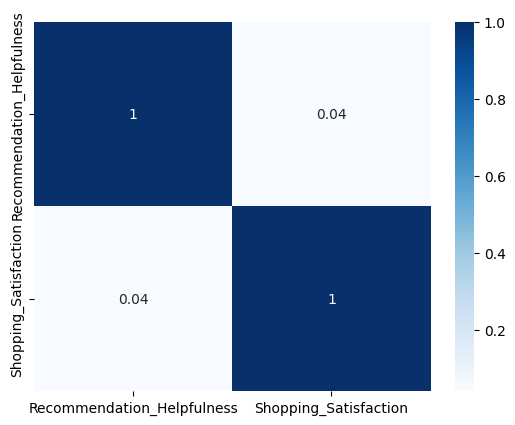

In [ ]:
import seaborn as sns
sns.heatmap(df[['Recommendation_Helpfulness', 'Shopping_Satisfaction']].corr(), annot=True, cmap='Blues');

In [ ]:
pd.crosstab(
    df['Recommendation_Helpfulness'],
    df['Shopping_Satisfaction'],
    normalize='index'
).round(3) * 100

Shopping_Satisfaction,1,2,3,4,5
Recommendation_Helpfulness,,,,,
1,20.7,22.4,22.7,15.9,18.3
2,18.4,19.7,21.7,16.0,24.2
3,19.2,19.2,21.8,20.3,19.5


In [ ]:
# The Correlation is almost negligible but slightly positive => 0.04
# Also shows that customer's Overall Satisfaction does not entirely depend on Recommendation Helpfulness
# If the recommendation helpfulness is No then the satisfaction level is
# also on the lower end than those customers who said Sometimes or Yes

## Review reliability and helpfulness impact on overall satisfaction

In [ ]:
df['Review_Helpfulness'].unique()

array(['No', 'Sometimes', 'Yes'], dtype=object)

In [ ]:
# Encoding column Review_Helpfulness
df['Review_Helpfulness'] = df['Review_Helpfulness'].map(rec)

In [ ]:
df['Review_Reliability'].unique()

array(['Rarely', 'Never', 'Moderately', 'Occasionally', 'Heavily'],
      dtype=object)

In [ ]:
rel = {
    'Never': 1,
    'Rarely': 2,
    'Occasionally': 3,
    'Moderately': 4,
    'Heavily': 5
}
df['Review_Reliability'] = df['Review_Reliability'].map(rel)


In [ ]:
# Impact of Review_Helpfulness on Satisfaction
df.groupby('Review_Helpfulness')[
    'Shopping_Satisfaction'
].mean().round(2)

,Shopping_Satisfaction
Review_Helpfulness,
1,2.93
2,3.05
3,2.99


In [ ]:
# Impact of Review_Reliability on Satisfaction
df.groupby('Review_Reliability')[
    'Shopping_Satisfaction'
].mean().round(2)

,Shopping_Satisfaction
Review_Reliability,
1,2.95
2,2.95
3,3.01
4,2.95
5,3.08


In [ ]:
df[['Review_Helpfulness', 'Review_Reliability', 'Shopping_Satisfaction']].corr().round(2)

,Review_Helpfulness,Review_Reliability,Shopping_Satisfaction
Review_Helpfulness,1.00,-0.02,0.02
Review_Reliability,-0.02,1.00,0.02
Shopping_Satisfaction,0.02,0.02,1.00


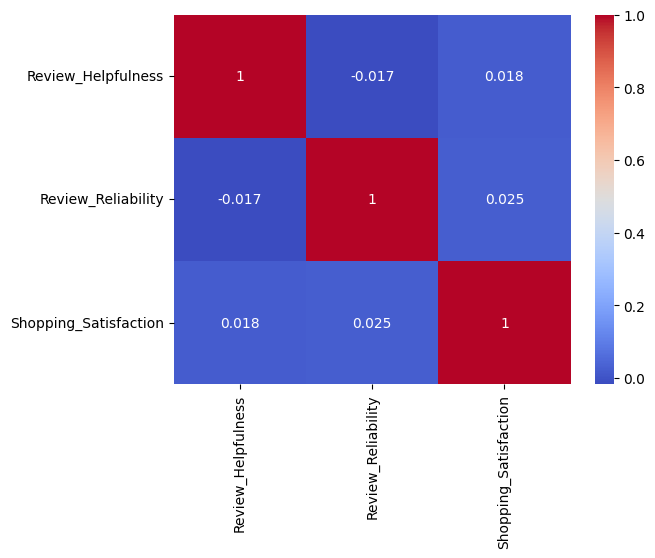

In [ ]:
sns.heatmap(df[['Review_Helpfulness', 'Review_Reliability', 'Shopping_Satisfaction']].corr(), annot=True, cmap='coolwarm');

In [ ]:
# Slightly Positive impact on overall Rating. Corrrelation => 0.02
# Average Rating is more for the customers who reported 5 as Review_Reliability
# But almost Similar avg Ratings for each class of Review Helpfulness and Reliability

## Personalized Recommendation Engagement

In [ ]:
df['Personalized_Recommendation_Frequency'].value_counts()

,count
Personalized_Recommendation_Frequency,
1,173
2,166
3,163
4,155
5,143


/tmp/ipykernel_2875/1750733829.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Personalized_Recommendation_Frequency', palette='Set2');


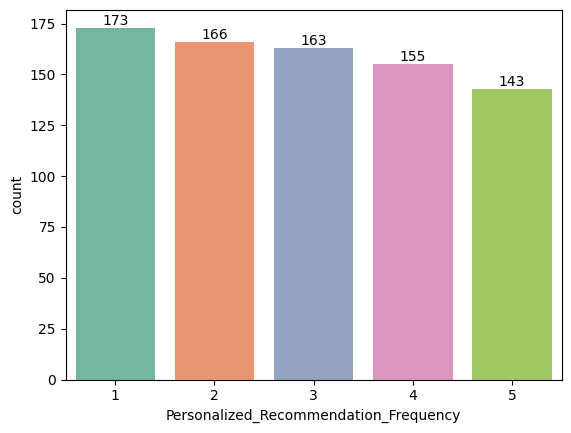

In [ ]:
ax = sns.countplot(data=df, x='Personalized_Recommendation_Frequency', palette='Set2');
for p in ax.containers:
    ax.bar_label(p)

In [1]:
# Personalized Recommendation Frequency shows a decreasing count trend from 1 to 5.

In [ ]:
df['Personalized_Recommendation_Frequency'].value_counts(normalize=True).round(4)*100

,proportion
Personalized_Recommendation_Frequency,
1,21.62
2,20.75
3,20.37
4,19.38
5,17.88


In [ ]:
# Correlation between Personalized Recommendation Frequency and Satisfaction Level 0.017
df[['Personalized_Recommendation_Frequency','Shopping_Satisfaction']].corr()

,Personalized_Recommendation_Frequency,Shopping_Satisfaction
Personalized_Recommendation_Frequency,1.000000,0.017207
Shopping_Satisfaction,0.017207,1.000000


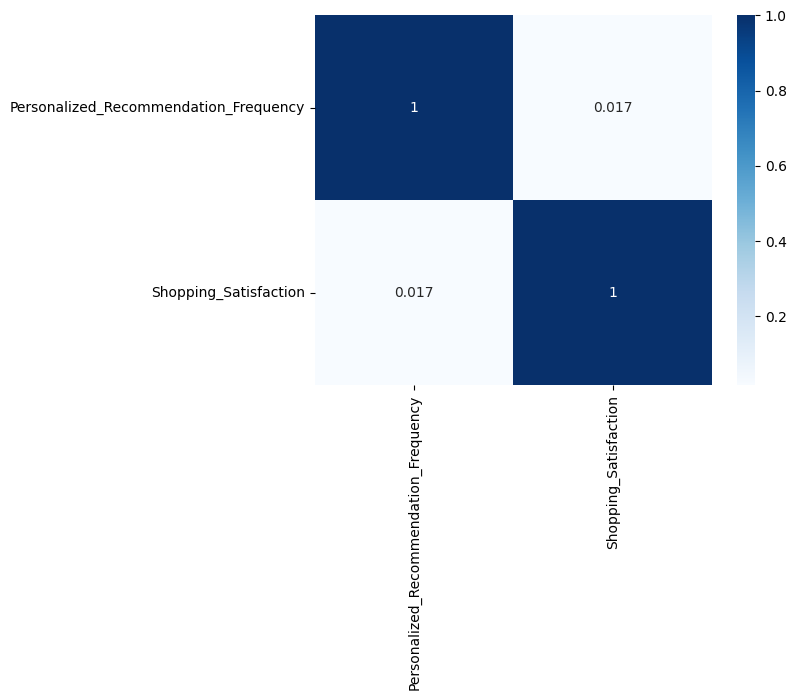

In [ ]:
sns.heatmap(df[['Personalized_Recommendation_Frequency','Shopping_Satisfaction']].corr(), annot=True, cmap='Blues');

In [ ]:
# Personalized Recommendation Frequency 1 and 5 have low percentages for higher satisfaction level
pd.crosstab(
    df['Personalized_Recommendation_Frequency'],
    df['Shopping_Satisfaction'],
    normalize='index'
).round(3) * 100

Shopping_Satisfaction,1,2,3,4,5
Personalized_Recommendation_Frequency,,,,,
1,20.2,25.4,22.5,13.9,17.9
2,19.3,18.7,21.1,18.1,22.9
3,18.4,16.0,27.0,16.6,22.1
4,19.4,18.1,21.9,20.0,20.6
5,20.3,24.5,17.5,18.9,18.9


In [ ]:
# Personalized Recommendation Frequency 1 and 5 have low avg satisfaction level
df.groupby('Personalized_Recommendation_Frequency')[
    'Shopping_Satisfaction'
].mean().round(2)

,Shopping_Satisfaction
Personalized_Recommendation_Frequency,
1,2.84
2,3.07
3,3.08
4,3.05
5,2.92


### Recommendation Engagement by Customer Segment

In [ ]:
# Avg. Personalized Recommendation Frequency is highest for cluster 2 (occassional) and lowest for 0 and 3 (high purchase freqency)
# Personalized Recommendation can be more and better for 0 and 3 cluster
df.groupby('Cluster')[
    ['Personalized_Recommendation_Frequency',
     'Shopping_Satisfaction']
].mean().round(2)

,Personalized_Recommendation_Frequency,Shopping_Satisfaction
Cluster,,
0,2.89,4.13
1,2.92,1.51
2,3.00,3.95
3,2.84,1.83


In [ ]:
# Recommendation Helpfulness is higher for more Satisfied Clusters 0 and 2
df.groupby('Cluster')[
    ['Recommendation_Helpfulness',
     'Shopping_Satisfaction']
].mean().round(2)

,Recommendation_Helpfulness,Shopping_Satisfaction
Cluster,,
0,1.98,4.13
1,1.87,1.51
2,2.01,3.95
3,1.97,1.83


## Actionable insights for improving Snapdeal’s recommendation system.

**Increase** the frequency and quality of **personalized recommendations** for the **high purchasing customers** (Cluster 0 and 3) using their purchase history, browsing behavior, and category preferences.

 Use **segment-specific recommendation frequency** rather than applying a uniform recommendation strategy, relevant recommendations for high-frequency customers while avoiding excessive recommendations for less-engaged users.

Focus on **recommendation quality and personalisation** rather than only increasing frequency. There is very low correlation between recommendation helpfulness and satisfaction (0.04)

 Snapdeal should **focus on verified reviews** and accurate product ratings to build trust. Since review reliability and helpfulness have almost no correlation with overall ratings (0.02 each).